## **GROUP PROJECT - WALMART SUPPLY CHAIN AI**

**Team members:**

**Srinivas Kapagunta**

**Phani Varshini Jasti**

**Vishva Ghanshyambhai Golaviya**

**Chih Wei Chuang**

## **Problem Statement**

Walmart is adopting a next-generation AI-powered supply chain, integrating automation, AI forecasting, robotics, IoT, and autonomous vehicles into its global logistics system.

While this offers efficiency, it introduces multiple new risks: cybersecurity, regulatory compliance, workforce disruptions, vendor dependencies, and AI model failures.

Our objective is to quantitatively assess, prioritize, and analyze these risks using structured risk scoring models and machine learning techniques to support proactive enterprise risk management (ERM).

**Importing Libraries**

In [1]:
#imports
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the Excel file
walmart = pd.read_excel('risk_register.xlsx')
walmart.head()

,Risk #,The Risk of/That,Likelihood Score,Impact Score
0,1,Maintainance costs,4,2
1,2,Techn obsolescence,2,2
2,3,Vendor Lock-In with increased cost of upgrades...,6,8
3,4,Legal and litigation costs of compliance settl...,1,9
4,5,Cost Savings through tech efficiency,3,8


**Analysing the table**

In [3]:
# Display columns
print(walmart.columns)

# Quick check for missing values
print(walmart.isnull().sum())

# Preview data
walmart.head()


Index(['Risk #', 'The Risk of/That', 'Likelihood Score', 'Impact Score'], dtype='object')
Risk #              0
The Risk of/That    0
Likelihood Score    0
Impact Score        0
dtype: int64


,Risk #,The Risk of/That,Likelihood Score,Impact Score
0,1,Maintainance costs,4,2
1,2,Techn obsolescence,2,2
2,3,Vendor Lock-In with increased cost of upgrades...,6,8
3,4,Legal and litigation costs of compliance settl...,1,9
4,5,Cost Savings through tech efficiency,3,8


We found that we haven't had any null values. So the dataset is good to perform further actions.

**Risk Score cal**

In [5]:
# Calculate Risk Score: Likelihood × Impact
walmart['Score'] = walmart['Likelihood Score'] * walmart['Impact Score']

# Preview updated data
walmart.head()


,Risk #,The Risk of/That,Likelihood Score,Impact Score,Score
0,1,Maintainance costs,4,2,8
1,2,Techn obsolescence,2,2,4
2,3,Vendor Lock-In with increased cost of upgrades...,6,8,48
3,4,Legal and litigation costs of compliance settl...,1,9,9
4,5,Cost Savings through tech efficiency,3,8,24


**Risk cal**

In [6]:
# Define Risk Level based on Score thresholds
def risk_level(score):
    if score >= 60:
        return 'High'
    elif score >= 30:
        return 'Medium'
    else:
        return 'Low'

# Apply the function
walmart['Risk Level'] = walmart['Score'].apply(risk_level)

# Preview updated data
walmart.head()


,Risk #,The Risk of/That,Likelihood Score,Impact Score,Score,Risk Level
0,1,Maintainance costs,4,2,8,Low
1,2,Techn obsolescence,2,2,4,Low
2,3,Vendor Lock-In with increased cost of upgrades...,6,8,48,Medium
3,4,Legal and litigation costs of compliance settl...,1,9,9,Low
4,5,Cost Savings through tech efficiency,3,8,24,Low


In [10]:
walmart['Risk Level'].value_counts()

,count
Risk Level,
Low,18
Medium,13
High,1


In order to have an easy understand of what's happening, we added "level" column by categorizing risks into high, medium and low

## **HeatMap Visual**

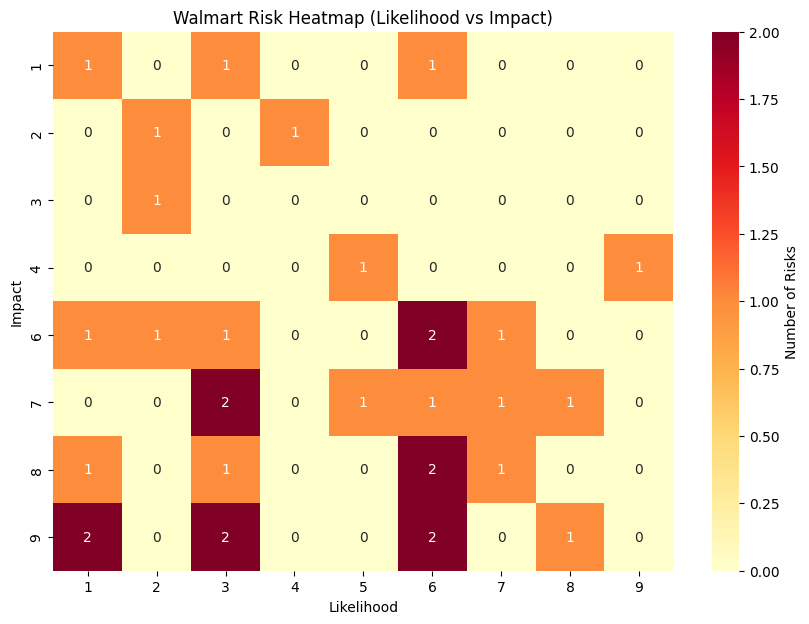

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create pivot table for heatmap
pivot = walmart.pivot_table(values='Score', index='Impact Score', columns='Likelihood Score', aggfunc='count', fill_value=0)

# Plot heatmap
plt.figure(figsize=(10,7))
sns.heatmap(pivot, annot=True, fmt="d", cmap="YlOrRd", cbar_kws={'label': 'Number of Risks'})
plt.title("Walmart Risk Heatmap (Likelihood vs Impact)")
plt.xlabel("Likelihood")
plt.ylabel("Impact")
plt.show()


**Explanation:**
The heatmap illustrates the distribution of Walmart’s supply chain risks based on their likelihood and impact scores. A significant concentration of risks lies in the high-impact categories (scores 6 to 9), even for risks with moderate likelihood.

This indicates that many of Walmart’s identified risks, while not always highly probable, can have severe consequences if realized. Notably, several risks with low likelihood but extremely high impact highlight rare but potentially catastrophic events, such as cybersecurity breaches or regulatory non-compliance.

The pattern also shows a moderate number of risks with likelihood scores ranging from 5 to 7, representing risks that are reasonably possible and warrant active monitoring. Overall, the heatmap reflects Walmart’s need for proactive risk management, focusing on both preventive measures and contingency planning for high-impact scenarios.

## **Risk count graphs**

In [15]:
# Risk Level count summary
risk_count = walmart['Risk Level'].value_counts()
print(risk_count)


Risk Level
Low       18
Medium    13
High       1
Name: count, dtype: int64


In [16]:
import plotly.express as px

fig = px.bar(
    x=risk_count.index,
    y=risk_count.values,
    color=risk_count.index,
    labels={'x': 'Risk Level', 'y': 'Count'},
    title="Distribution of Risk Levels in Walmart Supply Chain"
)
fig.show()


## **Correlation Analysis**

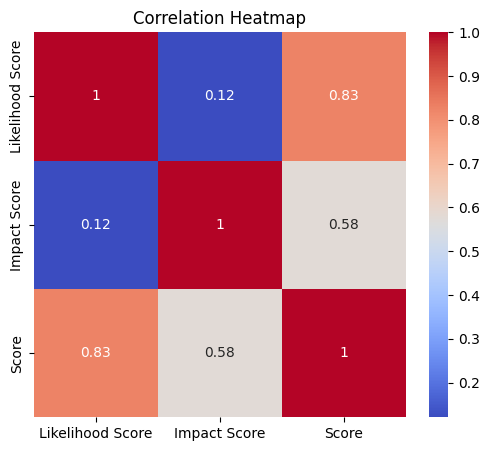

In [19]:
# Correlation between Likelihood, Impact, Score
plt.figure(figsize=(6,5))
sns.heatmap(walmart[['Likelihood Score','Impact Score','Score']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


## **Preparing for ML**

In [20]:
# First, map Risk Level into numeric labels for ML
level_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
walmart['Risk_Level_Label'] = walmart['Risk Level'].map(level_mapping)

# Check the data
walmart[['Likelihood Score', 'Impact Score', 'Risk Level', 'Risk_Level_Label']].head()


,Likelihood Score,Impact Score,Risk Level,Risk_Level_Label
0,4,2,Low,0
1,2,2,Low,0
2,6,8,Medium,1
3,1,9,Low,0
4,3,8,Low,0


## **Train-Test**

In [21]:
from sklearn.model_selection import train_test_split

# Features: Likelihood & Impact
X = walmart[['Likelihood Score', 'Impact Score']]

# Target: Risk Level (numeric labels)
y = walmart['Risk_Level_Label']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


## **Training Random Classifier**

In [22]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

              precision    recall  f1-score   support

           0       1.00      0.86      0.92         7
           1       0.75      1.00      0.86         3

    accuracy                           0.90        10
   macro avg       0.88      0.93      0.89        10
weighted avg       0.93      0.90      0.90        10



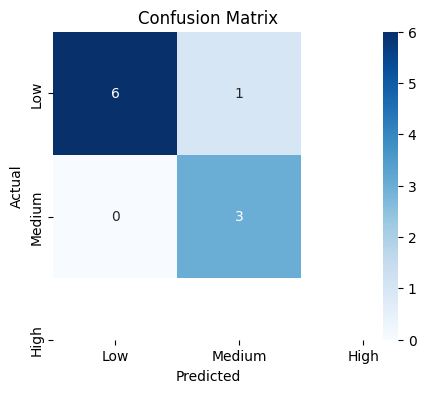

In [23]:
from sklearn.metrics import classification_report, confusion_matrix

# Make predictions
y_pred = model.predict(X_test)

# Classification report
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Low','Medium','High'], yticklabels=['Low','Medium','High'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


## **Interpretation**

The Random Forest classifier was trained to predict Walmart’s risk levels based on Likelihood and Impact scores. The confusion matrix and classification report summarize how well the model performed.

The model achieved an overall accuracy of 90%, meaning 9 out of 10 predictions were correct.

**For Low Risk (Class 0):**

The model correctly predicted 6 out of 7 low-risk cases.

1 low-risk case was misclassified as medium-risk.

**For Medium Risk (Class 1):**

The model correctly predicted all 3 medium-risk cases (perfect recall for this class).

No High Risk cases were present in this particular test sample, so the model only evaluated Low and Medium risks.

The precision and recall scores are strong for both classes, indicating balanced performance without heavy bias toward any one risk level.